In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

print("All libraries loaded successfully!")

All libraries loaded successfully!


Remaining NaNs: 0


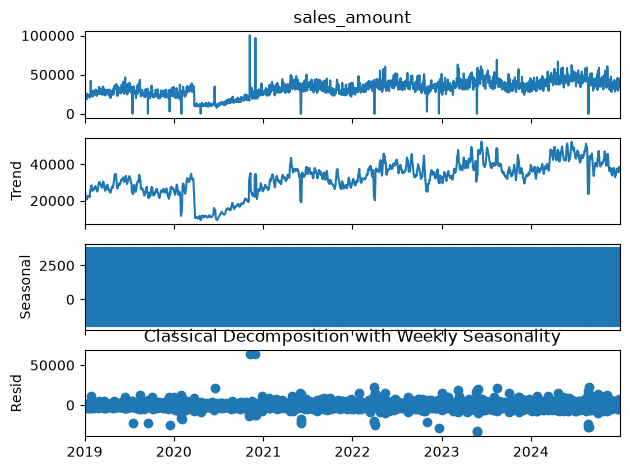

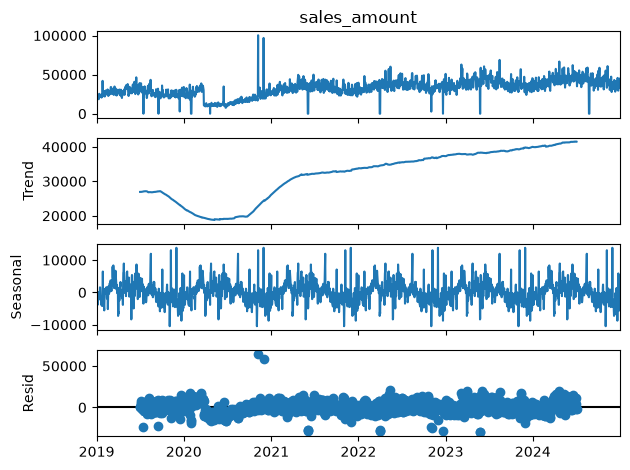

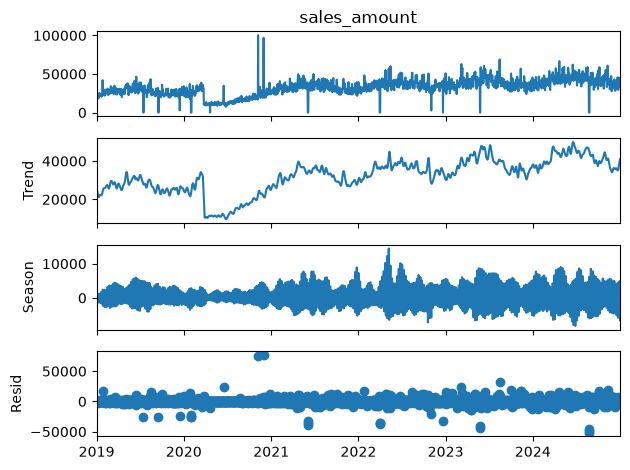

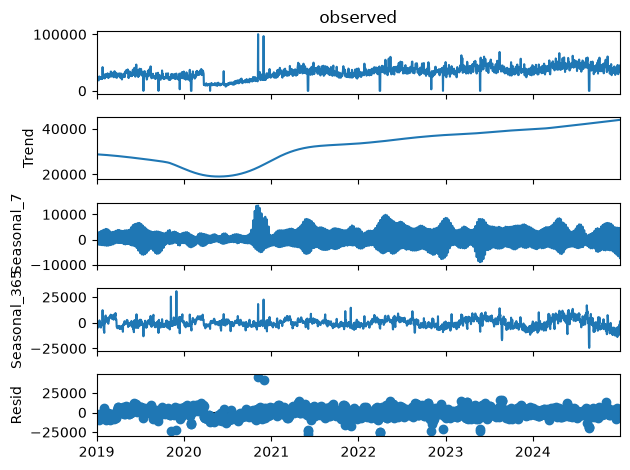

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL, MSTL

df = pd.read_csv('sales_forecasting_dataset.csv', parse_dates=['date'])

# 1. Pick ONE series
s = df[(df.store_id == 'Store_A') & (df.category == 'Beverages')].copy()
s = s.set_index('date').sort_index()

# 2. Make the calendar complete (exposes the 3 missing dates as NaN)
s = s.asfreq('D')

# 3. Fill gaps in the target (time-based interpolation)
y = s['sales_amount'].interpolate(method='time')
print("Remaining NaNs:", y.isna().sum())

# 4a. Classical decomposition, weekly seasonality
dec_weekly = seasonal_decompose(y, model='additive', period=7)
dec_weekly.plot()
plt.title("Classical Decomposition with Weekly Seasonality")
plt.show()

# 4b. Classical decomposition, yearly seasonality
dec_yearly = seasonal_decompose(y, model='additive', period=365)
dec_yearly.plot()
plt.show()

# 4c. Better: STL (robust to outliers, which this data has)
stl = STL(y, period=7, robust=True).fit()
stl.plot()
plt.show()

# 4d. Best for this data: MSTL, weekly AND yearly seasonality together
mstl = MSTL(y, periods=(7, 365)).fit()
mstl.plot()
plt.show()


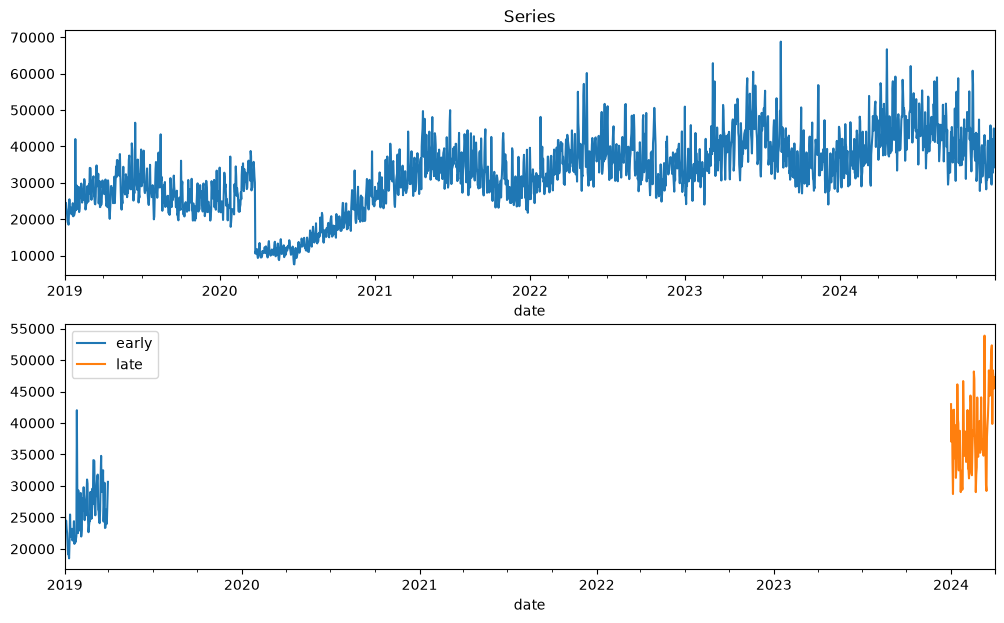

In [19]:
fig, ax = plt.subplots(2, 1, figsize=(12, 7))
y.plot(ax=ax[0], title='Series')
y['2019-01':'2019-03'].plot(ax=ax[1], label='early')
y['2024-01':'2024-03'].plot(ax=ax[1], label='late')
ax[1].legend(); plt.show()


Min value: 7583.07 | Zeros: 0


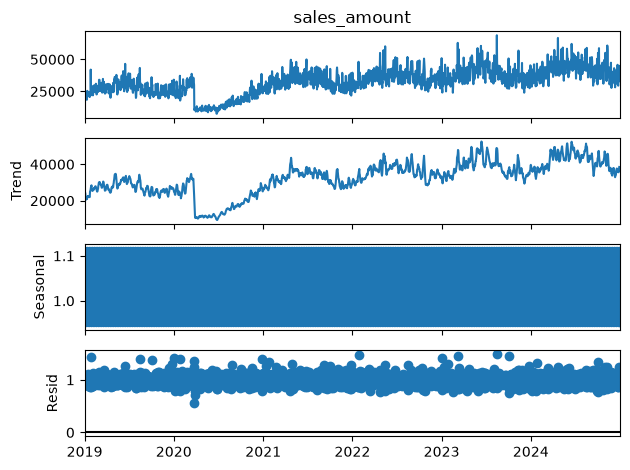

In [8]:
import numpy as np

y = s['sales_amount'].copy()

# Remove fake zeros and bad points, then fill
y[s['stockout_flag'] == 1] = np.nan
y[s['outlier_flag'] == 1] = np.nan
y = y.interpolate(method='time')

# Check that it's strictly positive
print("Min value:", y.min(), "| Zeros:", (y <= 0).sum())

# Multiplicative classical decomposition
dec_mul = seasonal_decompose(y, model='multiplicative', period=7)
dec_mul.plot()
plt.show()

In [15]:
import numpy as np

s = df[(df.store_id == 'Store_A') & (df.category == 'Beverages')].copy()
s = s.set_index('date').sort_index().asfreq('D')

y = s['sales_amount'].copy()

# Remove fake zeros and bad points
y[s['stockout_flag'] == 1] = np.nan
y[s['outlier_flag'] == 1] = np.nan

# Safety net: anything still <= 0 is treated as missing
y[y <= 0] = np.nan

# Fill gaps, including the first and last rows if they are NaN
y = y.interpolate(method='time').bfill().ffill()

print("Min:", y.min(), "| NaNs:", y.isna().sum())   # min should be > 0, NaNs = 0

Min: 7583.07 | NaNs: 0


In [17]:
dec_add = seasonal_decompose(y, model='additive', period=7)
dec_mul = seasonal_decompose(y, model='multiplicative', period=7)

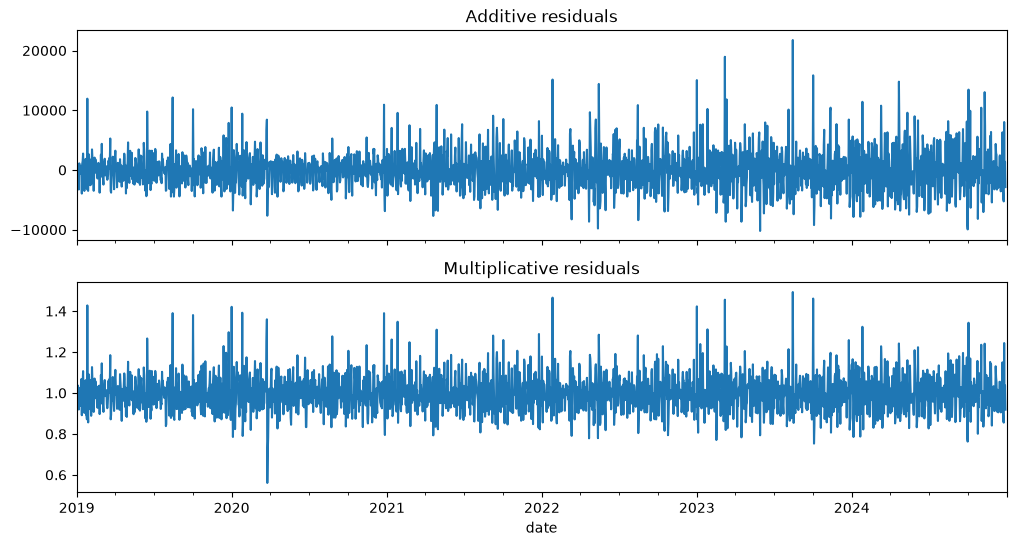

In [18]:
dec_add = seasonal_decompose(y, model='additive', period=7)
dec_mul = seasonal_decompose(y, model='multiplicative', period=7)

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
dec_add.resid.plot(ax=ax[0], title='Additive residuals')
dec_mul.resid.plot(ax=ax[1], title='Multiplicative residuals')
plt.show()

In [20]:
import numpy as np

fit_add = dec_add.trend + dec_add.seasonal
fit_mul = dec_mul.trend * dec_mul.seasonal

def metrics(actual, fit):
    e = (actual - fit).dropna()
    return pd.Series({'MAE': e.abs().mean(),
                      'RMSE': np.sqrt((e**2).mean()),
                      'MAPE%': (e.abs() / actual.loc[e.index]).mean() * 100})

print(pd.DataFrame({'additive': metrics(y, fit_add),
                    'multiplicative': metrics(y, fit_mul)}))

          additive  multiplicative
MAE    2392.383243     2306.069228
RMSE   3242.843831     3170.650624
MAPE%     7.558417        7.017800


In [21]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss

def adf_test(series, name='series', regression='c'):
    series = series.dropna()
    stat, p, lags, nobs, crit, _ = adfuller(series, regression=regression, autolag='AIC')
    print(f"--- ADF: {name} (regression='{regression}') ---")
    print(f"Statistic : {stat:.4f}")
    print(f"p-value   : {p:.4f}")
    print(f"Lags used : {lags}")
    for k, v in crit.items():
        print(f"Critical {k}: {v:.4f}")
    verdict = "STATIONARY" if p < 0.05 else "NON-STATIONARY"
    print(f"Result    : {verdict}\n")
    return p < 0.05

def kpss_test(series, name='series', regression='c'):
    series = series.dropna()
    stat, p, lags, crit = kpss(series, regression=regression, nlags='auto')
    print(f"--- KPSS: {name} (regression='{regression}') ---")
    print(f"Statistic : {stat:.4f}")
    print(f"p-value   : {p:.4f}")
    print(f"Lags used : {lags}")
    for k, v in crit.items():
        print(f"Critical {k}: {v:.4f}")
    verdict = "NON-STATIONARY" if p < 0.05 else "STATIONARY"
    print(f"Result    : {verdict}\n")
    return p >= 0.05

def stationarity_check(series, name='series', regression='c'):
    adf_ok = adf_test(series, name, regression)
    kpss_ok = kpss_test(series, name, regression)
    if adf_ok and kpss_ok:
        msg = "Stationary (both agree)"
    elif not adf_ok and not kpss_ok:
        msg = "Non-stationary (both agree) -> difference it"
    elif adf_ok and not kpss_ok:
        msg = "Difference-stationary / trend-stationary issue -> detrend or difference"
    else:
        msg = "Inconclusive (ADF fails, KPSS passes) -> often needs differencing; check plots"
    print(f"=== Combined verdict for {name}: {msg} ===\n")

# Run on the cleaned multiplicative-friendly series
# Time-based split, never random
train = y[:'2023']
test  = y['2024':]

stationarity_check(np.log(train), 'log(train)')

--- ADF: log(train) (regression='c') ---
Statistic : -2.0096
p-value   : 0.2824
Lags used : 25
Critical 1%: -3.4340
Critical 5%: -2.8631
Critical 10%: -2.5676
Result    : NON-STATIONARY

--- KPSS: log(train) (regression='c') ---
Statistic : 2.9872
p-value   : 0.0100
Lags used : 26
Critical 10%: 0.3470
Critical 5%: 0.4630
Critical 2.5%: 0.5740
Critical 1%: 0.7390
Result    : NON-STATIONARY

=== Combined verdict for log(train): Non-stationary (both agree) -> difference it ===



C:\Users\Aman\AppData\Local\Temp\ipykernel_29724\4036032445.py:7: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, p, lags, nobs, crit, _ = adfuller(series, regression=regression, autolag='AIC')
C:\Users\Aman\AppData\Local\Temp\ipykernel_29724\4036032445.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  stat, p, lags, crit = kpss(series, regression=regression, nlags='auto')
C:\Users\Aman\AppData\Local\Temp\ipykernel_29724\4036032445.py:20: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and whic

In [23]:
import numpy as np
from scipy.optimize import minimize_scalar

def guerrero_lambda(series, block=7, bounds=(-1, 2)):
    x = series.dropna().values
    n = (len(x) // block) * block
    blocks = x[:n].reshape(-1, block)
    mean = blocks.mean(axis=1)
    std = blocks.std(axis=1, ddof=1)

    def cv_of_ratio(lam):
        ratio = std / mean ** (1 - lam)
        return ratio.std(ddof=1) / ratio.mean()

    res = minimize_scalar(cv_of_ratio, bounds=bounds, method='bounded')
    return res.x

lam_g = guerrero_lambda(train, block=7)
print("Guerrero lambda:", lam_g)

Guerrero lambda: 0.12261164482893541


In [25]:
from scipy.stats import boxcox

def spread_by_year(s):
    d = s.diff(7).dropna()          # remove level + weekly pattern
    return d.groupby(d.index.year).std().round(3)

print(pd.DataFrame({
    'raw': spread_by_year(train),
    'log': spread_by_year(np.log(train)),
    f'boxcox λ={lam_g:.2f}': spread_by_year(pd.Series(boxcox(train, lmbda=lam_g), index=train.index)),
}))
print(pd.DataFrame({
    'raw': spread_by_year(train),
    'log': spread_by_year(np.log(train)),
    'boxcox 0.12': spread_by_year(pd.Series(boxcox(train, lmbda=0.12), index=train.index)),
}))

           raw    log  boxcox λ=0.12
date                                
2019  4788.056  0.172          0.601
2020  4752.860  0.227          0.762
2021  5586.991  0.167          0.598
2022  6625.271  0.176          0.639
2023  7847.740  0.193          0.706
           raw    log  boxcox 0.12
date                              
2019  4788.056  0.172        0.585
2020  4752.860  0.227        0.743
2021  5586.991  0.167        0.582
2022  6625.271  0.176        0.621
2023  7847.740  0.193        0.687


In [26]:
import warnings
warnings.filterwarnings('ignore')
train_log = np.log(train)

d1   = train_log.diff().dropna()
d7   = train_log.diff(7).dropna()
d1_7 = train_log.diff().diff(7).dropna()

for name, s_ in {'log diff(1)': d1,
                 'log diff(7)': d7,
                 'log diff(1)+diff(7)': d1_7}.items():
    stationarity_check(s_, name)

--- ADF: log diff(1) (regression='c') ---
Statistic : -11.0744
p-value   : 0.0000
Lags used : 25
Critical 1%: -3.4340
Critical 5%: -2.8631
Critical 10%: -2.5676
Result    : STATIONARY

--- KPSS: log diff(1) (regression='c') ---
Statistic : 0.0638
p-value   : 0.1000
Lags used : 77
Critical 10%: 0.3470
Critical 5%: 0.4630
Critical 2.5%: 0.5740
Critical 1%: 0.7390
Result    : STATIONARY

=== Combined verdict for log diff(1): Stationary (both agree) ===

--- ADF: log diff(7) (regression='c') ---
Statistic : -9.0120
p-value   : 0.0000
Lags used : 25
Critical 1%: -3.4340
Critical 5%: -2.8632
Critical 10%: -2.5676
Result    : STATIONARY

--- KPSS: log diff(7) (regression='c') ---
Statistic : 0.0328
p-value   : 0.1000
Lags used : 16
Critical 10%: 0.3470
Critical 5%: 0.4630
Critical 2.5%: 0.5740
Critical 1%: 0.7390
Result    : STATIONARY

=== Combined verdict for log diff(7): Stationary (both agree) ===

--- ADF: log diff(1)+diff(7) (regression='c') ---
Statistic : -17.0754
p-value   : 0.0000
L

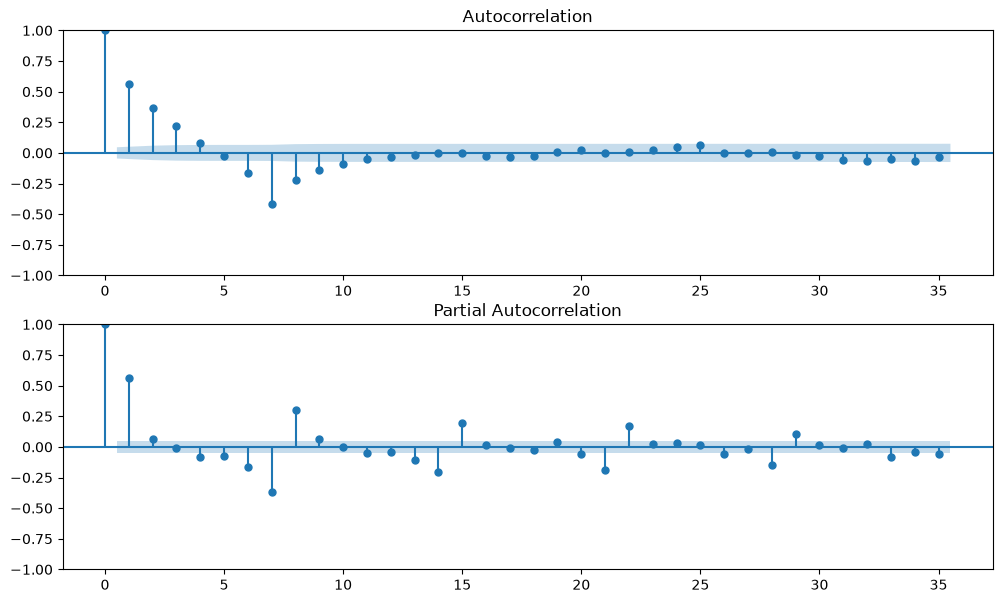

In [27]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

stat_series = d7   # use whichever series passed (d1_7, d7, ...)

fig, ax = plt.subplots(2, 1, figsize=(12, 7))
plot_acf(stat_series, lags=35, ax=ax[0])
plot_pacf(stat_series, lags=35, ax=ax[1], method='ywm')
plt.show()

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(actual, pred, name):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = (np.abs(actual - pred) / actual).mean() * 100
    print(f"{name:25s} MAE={mae:9.1f}  RMSE={rmse:9.1f}  MAPE={mape:5.1f}%")

# Seasonal naive: same weekday last week
h = len(test)
snaive = pd.Series(np.tile(train[-7:].values, h // 7 + 1)[:h], index=test.index)
evaluate(test, snaive, 'Seasonal naive (7)')

Seasonal naive (7)        MAE=   7956.1  RMSE=   9772.6  MAPE= 18.5%


In [29]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

train_log = np.log(train)

model = SARIMAX(train_log,
                order=(1, 0, 1),               # (p, d, q): set d from your result
                seasonal_order=(1, 1, 1, 7),   # (P, D, Q, m)
                enforce_stationarity=False,
                enforce_invertibility=False)
res = model.fit(disp=False)
print(res.summary())

# Forecast the test period and undo the log
fc_log = res.get_forecast(steps=len(test))
fc = np.exp(fc_log.predicted_mean)
fc.index = test.index
evaluate(test, fc, 'SARIMA')

                                     SARIMAX Results                                     
Dep. Variable:                      sales_amount   No. Observations:                 1826
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 7)   Log Likelihood                1326.157
Date:                           Fri, 09 Oct 2026   AIC                          -2642.315
Time:                                   15:58:43   BIC                          -2614.809
Sample:                               01-01-2019   HQIC                         -2632.164
                                    - 12-31-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9716      0.007    138.502      0.000       0.958       0.985
ma.L1         -0.3960      0.019    -20.743

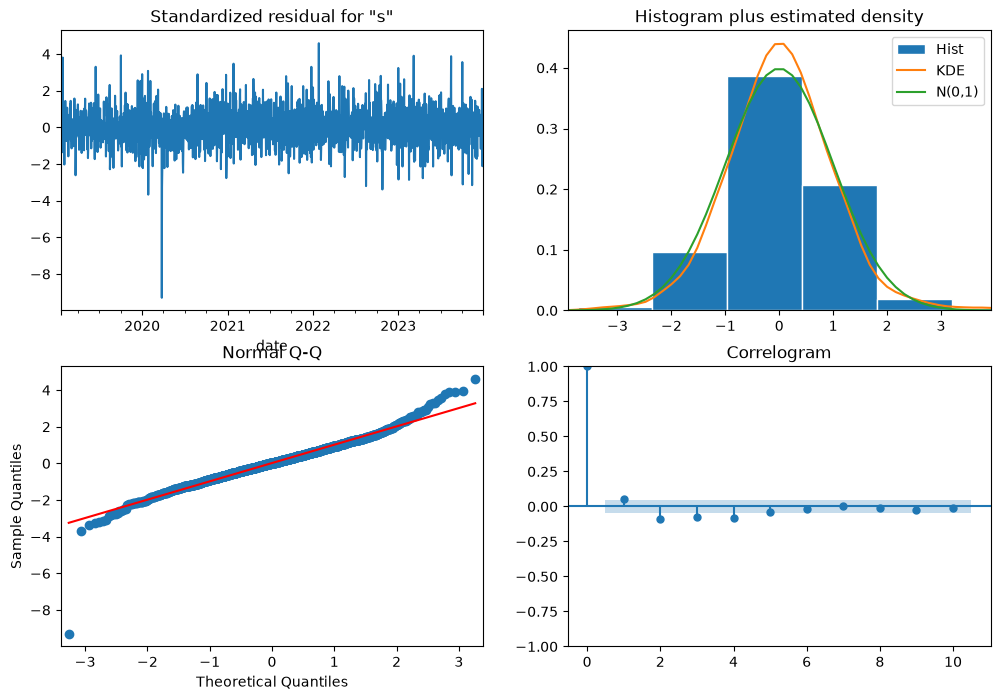

In [30]:
res.plot_diagnostics(figsize=(12, 8))
plt.show()

In [31]:
exog_cols = ['promo_flag', 'is_holiday', 'discount_pct']
X = s[exog_cols].asfreq('D').fillna(0)
X_train, X_test = X[:'2023'], X['2024':]

model_x = SARIMAX(train_log, exog=X_train,
                  order=(1, 0, 1), seasonal_order=(1, 1, 1, 7),
                  enforce_stationarity=False, enforce_invertibility=False)
res_x = model_x.fit(disp=False)

fc_x = np.exp(res_x.get_forecast(steps=len(test), exog=X_test).predicted_mean)
fc_x.index = test.index
evaluate(test, fc_x, 'SARIMAX')

SARIMAX                   MAE=   6174.1  RMSE=   7744.8  MAPE= 13.9%


In [32]:
print("Mean daily sales in test:", test.mean())
print("MAE as % of mean:", 6174 / test.mean() * 100)

Mean daily sales in test: 41855.934904371585
MAE as % of mean: 14.750596335037699


In [34]:
h = len(test)
snaive = pd.Series(np.tile(train[-7:].values, h // 7 + 1)[:h], index=test.index)
evaluate(test, snaive, 'Seasonal naive (7)')
evaluate(test, fc, 'SARIMA')          # the model without exog
evaluate(test, fc_x, 'SARIMAX')

Seasonal naive (7)        MAE=   7956.1  RMSE=   9772.6  MAPE= 18.5%
SARIMA                    MAE=   6796.9  RMSE=   8500.1  MAPE= 15.2%
SARIMAX                   MAE=   6174.1  RMSE=   7744.8  MAPE= 13.9%


In [36]:
test_log = np.log(test)

# Update the fitted model with test data WITHOUT refitting parameters
res_ahead = res_x.append(test_log, exog=X_test, refit=False)

pred = res_ahead.get_prediction(start=test.index[0], end=test.index[-1],
                                exog=X_test)
fc_1step = np.exp(pred.predicted_mean)
evaluate(test, fc_1step, 'SARIMAX 1-step-ahead')

SARIMAX 1-step-ahead      MAE=   3645.6  RMSE=   4576.7  MAPE=  8.8%


In [38]:
def fourier(idx, period=365.25, K=3):
    t = idx.dayofyear.values
    cols = {}
    for k in range(1, K + 1):
        cols[f'sin{k}'] = np.sin(2 * np.pi * k * t / period)
        cols[f'cos{k}'] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(cols, index=idx)

# Pre-festival build-up (7 days before Diwali / Holi)
fest = pd.to_datetime(['2019-10-27','2020-11-14','2021-11-04','2022-10-24','2023-11-12','2024-11-01',
                       '2019-03-21','2020-03-10','2021-03-29','2022-03-18','2023-03-08','2024-03-25'])
pre = pd.Series(0.0, index=X.index)
for d in fest:
    for k in range(1, 8):
        day = d - pd.Timedelta(days=k)
        if day in pre.index:
            pre[day] = (8 - k) / 7

X2 = pd.concat([X, fourier(X.index), pre.rename('pre_fest')], axis=1)
X2_train, X2_test = X2[:'2023'], X2['2024':]

m2 = SARIMAX(train_log, exog=X2_train,
             order=(1, 0, 0), seasonal_order=(0, 1, 1, 7),
             enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

fc2 = np.exp(m2.get_forecast(steps=len(test), exog=X2_test).predicted_mean)
fc2.index = test.index
evaluate(test, fc2, 'SARIMAX + Fourier + pre_fest')

SARIMAX + Fourier + pre_fest MAE=   5949.4  RMSE=   7410.9  MAPE= 13.5%


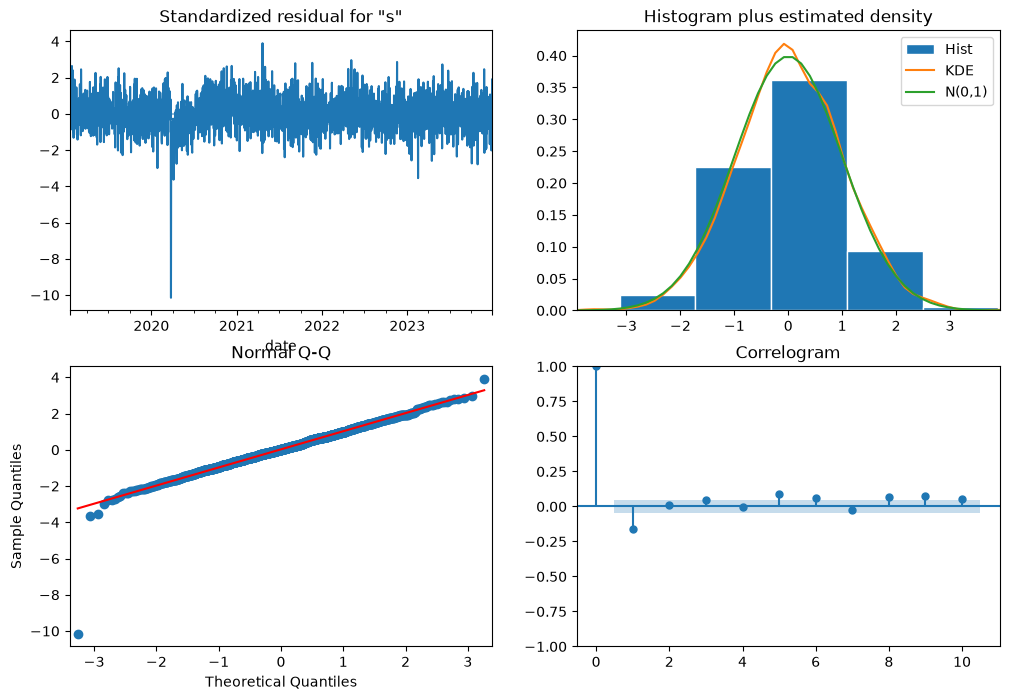

In [39]:
m2.plot_diagnostics(figsize=(12, 8)); plt.show()

In [40]:
idx = X.index

# Trend (in years)
trend = pd.Series((idx - idx[0]).days / 365.25, index=idx, name='trend')

# Weekday dummies (drop Monday)
wd = pd.get_dummies(idx.dayofweek, prefix='dow', drop_first=True).astype(float)
wd.index = idx

# Lockdown + recovery ramp, so the 2020 break stops distorting everything
lock = pd.Series(0.0, index=idx, name='lockdown')
lock[(idx >= '2020-03-25') & (idx <= '2020-06-30')] = 1.0
rec = (idx > '2020-06-30') & (idx <= '2020-12-27')
lock_rec = pd.Series(0.0, index=idx, name='recovery')
lock_rec[rec] = 1 - np.arange(rec.sum()) / rec.sum()

X3 = pd.concat([trend, wd, fourier(idx, K=4), pre.rename('pre_fest'),
                X[['is_holiday', 'promo_flag', 'discount_pct']],
                lock, lock_rec], axis=1)

X3_train, X3_test = X3[:'2023'], X3['2024':]

m3 = SARIMAX(train_log, exog=X3_train,
             order=(1, 0, 1),                # no differencing
             enforce_stationarity=False,
             enforce_invertibility=False).fit(disp=False)

fc3 = np.exp(m3.get_forecast(steps=len(test), exog=X3_test).predicted_mean)
fc3.index = test.index
evaluate(test, fc3, 'Regression + ARMA errors')

Regression + ARMA errors  MAE= 184655.6  RMSE= 541270.6  MAPE=504.1%


In [42]:
evaluate(test, snaive, 'Seasonal naive')
evaluate(test, fc_x,   'SARIMAX')
evaluate(test, fc2,    'SARIMAX + Fourier')
evaluate(test, fc3,    'Regression + ARMA')

Seasonal naive            MAE=   7956.1  RMSE=   9772.6  MAPE= 18.5%
SARIMAX                   MAE=   6174.1  RMSE=   7744.8  MAPE= 13.9%
SARIMAX + Fourier         MAE=   5949.4  RMSE=   7410.9  MAPE= 13.5%
Regression + ARMA         MAE= 184655.6  RMSE= 541270.6  MAPE=504.1%


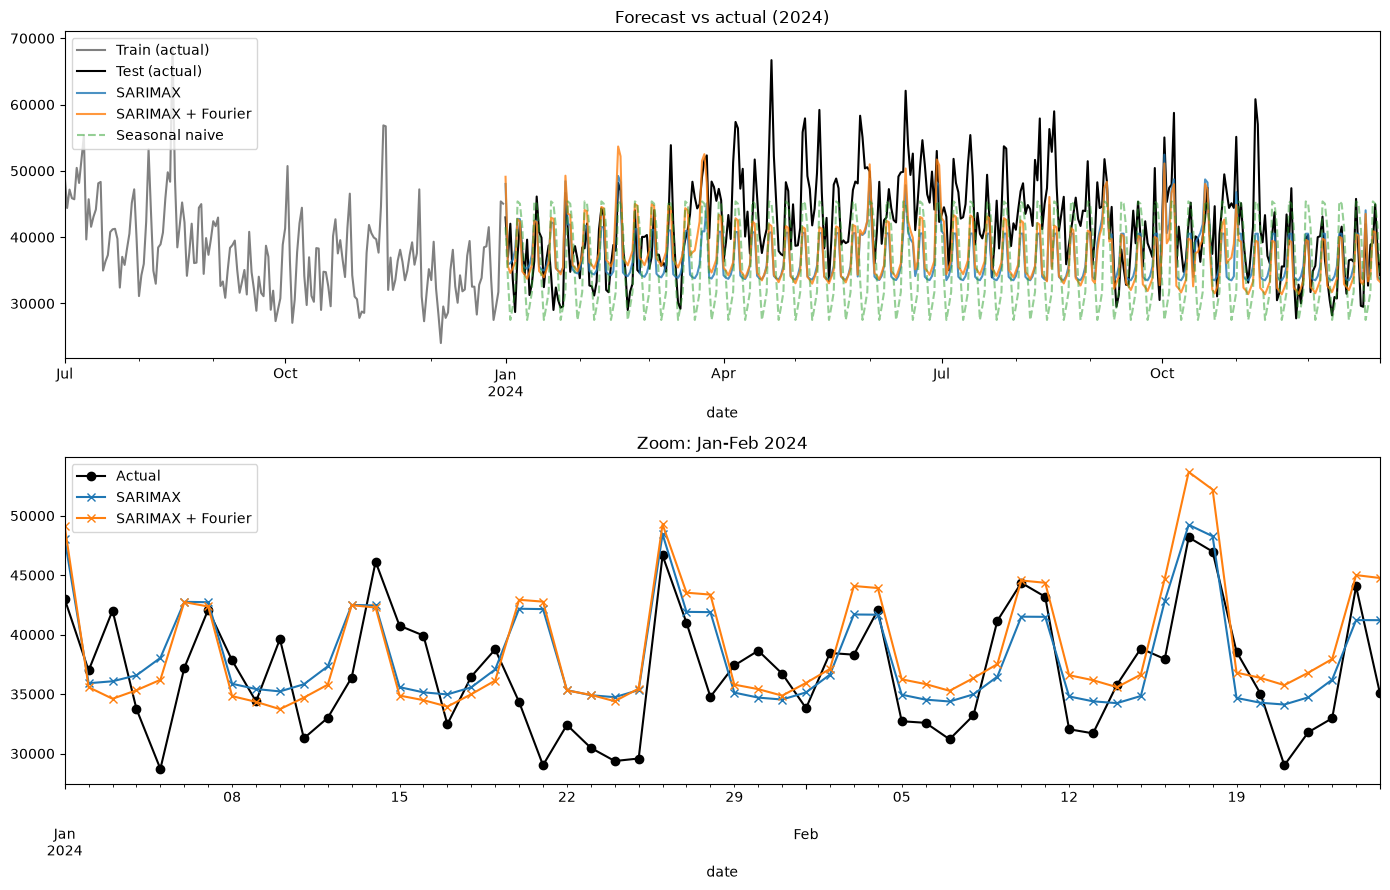

In [44]:
fig, ax = plt.subplots(2, 1, figsize=(14, 9))

# Full view: last year of train + test
train['2023-07':].plot(ax=ax[0], color='gray', label='Train (actual)')
test.plot(ax=ax[0], color='black', label='Test (actual)')
fc_x.plot(ax=ax[0],  label='SARIMAX',            alpha=0.8)
fc2.plot(ax=ax[0],   label='SARIMAX + Fourier',  alpha=0.8)
snaive.plot(ax=ax[0], label='Seasonal naive',    alpha=0.5, linestyle='--')
ax[0].set_title('Forecast vs actual (2024)')
ax[0].legend()

# Zoom: first 8 weeks of the test period
z = slice('2024-01-01', '2024-02-25')
test[z].plot(ax=ax[1], color='black', marker='o', label='Actual')
fc_x[z].plot(ax=ax[1],  marker='x', label='SARIMAX')
fc2[z].plot(ax=ax[1],   marker='x', label='SARIMAX + Fourier')
ax[1].set_title('Zoom: Jan-Feb 2024')
ax[1].legend()

plt.tight_layout(); plt.show()

In [45]:
import numpy as np, pandas as pd, statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

# s = Store_A / Beverages with .asfreq('D'); y = your cleaned sales_amount; train/test as before
idx = y.index
doy = idx.dayofyear.values

X = pd.DataFrame(index=idx)
X['t']      = (idx - idx[0]).days / 365.25
X['t_post'] = np.clip((idx - pd.Timestamp('2022-01-01')).days, 0, None) / 365.25  # slope change
for k in range(1, 4):
    X[f's{k}'] = np.sin(2*np.pi*k*doy/365.25)
    X[f'c{k}'] = np.cos(2*np.pi*k*doy/365.25)
for i in range(1, 7):
    X[f'dow{i}'] = (idx.dayofweek == i).astype(float)

X['hol']      = s['is_holiday'].values
X['pre']      = pre.values                         # pre-festival ramp from earlier
X['promo']    = s['promo_flag'].values
X['logprice'] = np.log(s['unit_price'].interpolate().values)
X['temp']     = s['temperature_c'].interpolate().values
X['mkt']      = s['marketing_spend'].interpolate().values / 1000

lock = ((idx >= '2020-03-25') & (idx <= '2020-06-30')).astype(float)
rec  = (idx > '2020-06-30') & (idx <= '2020-12-27')
X['lock'] = lock
X['rec']  = np.where(rec, 1 - (np.cumsum(rec) - 1) / rec.sum(), 0.0)

X = X.interpolate().bfill().ffill()          # fills the 3 missing dates
Xtr, Xte = X[:'2023'], X['2024':]

# 1) regression on log sales
ols = sm.OLS(np.log(train), sm.add_constant(Xtr)).fit()

# 2) AR(1) on the residuals
ar = ARIMA(ols.resid, order=(1, 0, 0)).fit()

# 3) forecast = regression part + AR part, then exp
reg = ols.predict(sm.add_constant(Xte, has_constant='add'))
fc5 = np.exp(reg + ar.forecast(len(test)).values)
fc5.index = test.index

evaluate(test, fc5, 'Log-regression + AR(1)')

Log-regression + AR(1)    MAE=   3315.3  RMSE=   4283.7  MAPE=  8.0%


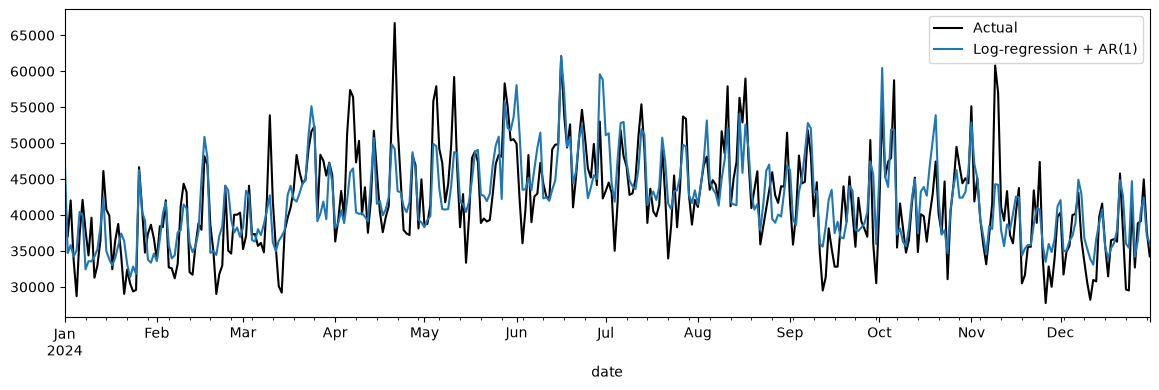

In [46]:
test.plot(color='black', label='Actual', figsize=(14, 4))
fc5.plot(label='Log-regression + AR(1)')
plt.legend(); plt.show()